# 05. Double/Debiased Machine Learning

Double/debiased machine learning (DML) is a framework for estimating low-dimensional causal parameters while using flexible machine learning to adjust for high-dimensional or nonlinear nuisance functions.

The key idea is not "use a powerful model and trust it." The key idea is to use machine learning in a way that protects the target causal estimate from first-order nuisance-model errors. DML does this with orthogonal scores and cross-fitting.

This notebook focuses on the partially linear DML estimator for a continuous treatment, then connects the same ideas to effect heterogeneity and binary-treatment scores.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why ordinary machine-learning adjustment is not automatically valid causal inference.
- Define nuisance functions and the target parameter in the partially linear model.
- Describe Neyman orthogonality in practical terms.
- Implement cross-fitted DML for a continuous treatment effect.
- Compare naive regression, misspecified linear adjustment, in-sample residualization, and cross-fitted DML.
- Interpret residual diagnostics, nuisance model quality, and confidence intervals.
- Understand how DML ideas connect to R-learners, DR-learners, and policy-oriented causal ML.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def simulate_intervention_intensity_data(n=10_000, p_noise=10, seed=5505):
    rng = np.random.default_rng(seed)

    risk_score = rng.beta(2.2, 2.6, n)
    engagement_score = rng.beta(2.4, 2.0, n)
    usage_z = rng.normal(0, 1, n)
    log_account_value = rng.normal(4.35, 0.58, n)
    account_value = np.exp(log_account_value)
    tenure_months = rng.gamma(2.2, 9.5, n)
    enterprise_plan = rng.binomial(1, sigmoid(-0.35 + 0.75 * (log_account_value - 4.35) + 0.50 * risk_score), n)
    support_tickets = rng.poisson(np.clip(0.7 + 3.0 * risk_score - 0.4 * usage_z + 0.6 * enterprise_plan, 0.1, None))
    integration_count = rng.poisson(np.clip(1.0 + 3.5 * engagement_score + 1.4 * enterprise_plan, 0.2, None))
    region_south = rng.binomial(1, 0.32, n)
    region_west = rng.binomial(1, 0.33, n) * (1 - region_south)

    nonlinear_risk_need = (risk_score > 0.62).astype(float) * (1 - engagement_score)
    engagement_wave = np.cos(2 * np.pi * engagement_score)
    very_new_account = (tenure_months < 7).astype(float)

    treatment_mean = (
        2.0
        + 1.2 * risk_score
        - 0.7 * usage_z
        + 0.45 * enterprise_plan
        + 0.18 * support_tickets
        + 0.15 * (log_account_value - 4.35)
        + 1.3 * nonlinear_risk_need
        - 0.9 * engagement_wave
        + 0.45 * very_new_account
        + 0.22 * region_south
        - 0.12 * region_west
    )
    treatment_intensity = treatment_mean + rng.normal(0, 0.9, n)

    structural_effect = 3.4
    baseline_outcome = (
        72
        + 0.13 * account_value
        + 6.5 * usage_z
        - 8.0 * risk_score
        + 4.2 * enterprise_plan
        + 0.08 * tenure_months
        + 1.1 * integration_count
        - 1.4 * support_tickets
        + 18.0 * nonlinear_risk_need
        + 9.0 * engagement_wave
        + 7.0 * very_new_account
        + 1.5 * region_west
        - 1.2 * region_south
        + 2.0 * np.sin(usage_z)
    )
    outcome = structural_effect * treatment_intensity + baseline_outcome + rng.normal(0, 7.0, n)

    data = {
        "account_id": np.arange(1, n + 1),
        "risk_score": risk_score,
        "engagement_score": engagement_score,
        "usage_z": usage_z,
        "log_account_value": log_account_value,
        "account_value": account_value,
        "tenure_months": tenure_months,
        "enterprise_plan": enterprise_plan,
        "support_tickets": support_tickets,
        "integration_count": integration_count,
        "region_south": region_south,
        "region_west": region_west,
        "nonlinear_risk_need": nonlinear_risk_need,
        "engagement_wave": engagement_wave,
        "very_new_account": very_new_account,
        "treatment_mean": treatment_mean,
        "treatment_intensity": treatment_intensity,
        "baseline_outcome": baseline_outcome,
        "outcome": outcome,
        "structural_effect": structural_effect,
    }
    for j in range(p_noise):
        data[f"noise_feature_{j + 1:02d}"] = rng.normal(0, 1, n)

    return pd.DataFrame(data)


def crossfit_predictions(frame, feature_cols, target_col, model, n_splits=5, seed=123):
    predictions = np.zeros(len(frame))
    fold_ids = np.zeros(len(frame), dtype=int)
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fold_id, (fit_idx, pred_idx) in enumerate(kfold.split(frame), start=1):
        fit_data = frame.iloc[fit_idx]
        pred_data = frame.iloc[pred_idx]
        fold_model = clone(model)
        fold_model.fit(fit_data[feature_cols], fit_data[target_col])
        predictions[pred_idx] = fold_model.predict(pred_data[feature_cols])
        fold_ids[pred_idx] = fold_id

    return predictions, fold_ids


def dml_partial_linear(frame, feature_cols, outcome_col, treatment_col, outcome_model, treatment_model, n_splits=5, seed=123):
    y_hat, fold_ids = crossfit_predictions(frame, feature_cols, outcome_col, outcome_model, n_splits=n_splits, seed=seed)
    d_hat, _ = crossfit_predictions(frame, feature_cols, treatment_col, treatment_model, n_splits=n_splits, seed=seed + 17)

    y_residual = frame[outcome_col].to_numpy() - y_hat
    d_residual = frame[treatment_col].to_numpy() - d_hat

    theta_hat = np.sum(d_residual * y_residual) / np.sum(d_residual**2)
    score = d_residual * (y_residual - theta_hat * d_residual)
    jacobian = np.mean(d_residual**2)
    std_error = np.sqrt(np.mean(score**2)) / (np.sqrt(len(frame)) * jacobian)

    diagnostics = pd.DataFrame(
        {
            "fold": fold_ids,
            "y_hat": y_hat,
            "d_hat": d_hat,
            "y_residual": y_residual,
            "d_residual": d_residual,
            "score": score,
        },
        index=frame.index,
    )

    return {
        "theta": theta_hat,
        "std_error": std_error,
        "ci_low": theta_hat - 1.96 * std_error,
        "ci_high": theta_hat + 1.96 * std_error,
        "diagnostics": diagnostics,
        "r2_y": r2_score(frame[outcome_col], y_hat),
        "r2_d": r2_score(frame[treatment_col], d_hat),
        "rmse_y": np.sqrt(mean_squared_error(frame[outcome_col], y_hat)),
        "rmse_d": np.sqrt(mean_squared_error(frame[treatment_col], d_hat)),
    }


def same_sample_residualization(frame, feature_cols, outcome_col, treatment_col, outcome_model, treatment_model):
    y_model = clone(outcome_model)
    d_model = clone(treatment_model)
    y_model.fit(frame[feature_cols], frame[outcome_col])
    d_model.fit(frame[feature_cols], frame[treatment_col])

    y_hat = y_model.predict(frame[feature_cols])
    d_hat = d_model.predict(frame[feature_cols])
    y_residual = frame[outcome_col].to_numpy() - y_hat
    d_residual = frame[treatment_col].to_numpy() - d_hat
    theta_hat = np.sum(d_residual * y_residual) / np.sum(d_residual**2)

    return {
        "theta": theta_hat,
        "r2_y": r2_score(frame[outcome_col], y_hat),
        "r2_d": r2_score(frame[treatment_col], d_hat),
        "d_residual_sd": np.std(d_residual),
    }


def estimate_linear_ols(frame, covariates=None):
    covariates = covariates or []
    X = sm.add_constant(frame[["treatment_intensity"] + covariates], has_constant="add")
    model = sm.OLS(frame["outcome"], X).fit(cov_type="HC3")
    return {
        "estimate": model.params["treatment_intensity"],
        "std_error": model.bse["treatment_intensity"],
        "ci_low": model.conf_int().loc["treatment_intensity", 0],
        "ci_high": model.conf_int().loc["treatment_intensity", 1],
    }

## 1. Why DML Exists

Machine learning is very good at predicting complicated functions. Causal inference often needs complicated functions too: treatment assignment models, outcome models, missingness models, mediator models, and so on.

The problem is that causal targets are usually not the prediction functions themselves. We often care about a low-dimensional parameter such as:

- The effect of one additional unit of treatment intensity.
- The average treatment effect of a binary intervention.
- A policy value.
- A treatment effect in a subgroup.

If we estimate nuisance functions with flexible ML and plug them into a causal formula naively, nuisance-model error can leak into the target estimate. DML is designed to reduce that leakage.

Chernozhukov et al. (2018) formalized DML for treatment and structural parameters. The two practical ingredients are:

- Orthogonal scores: estimating equations that are locally insensitive to nuisance-model errors.
- Cross-fitting: estimate nuisance functions on one part of the data and evaluate them on held-out observations.

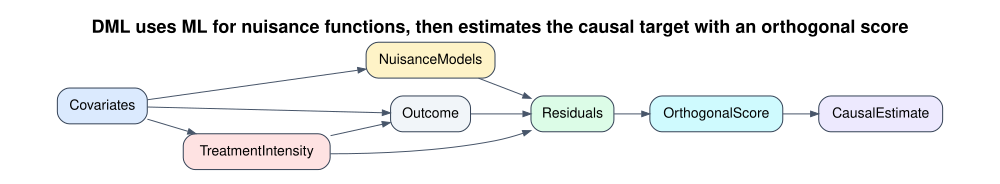

In [3]:
make_dag(
    edges=[
        ("Covariates", "TreatmentIntensity"),
        ("Covariates", "Outcome"),
        ("TreatmentIntensity", "Outcome"),
        ("Covariates", "NuisanceModels"),
        ("NuisanceModels", "Residuals"),
        ("TreatmentIntensity", "Residuals"),
        ("Outcome", "Residuals"),
        ("Residuals", "OrthogonalScore"),
        ("OrthogonalScore", "CausalEstimate"),
    ],
    title="DML uses ML for nuisance functions, then estimates the causal target with an orthogonal score",
    node_colors={
        "Covariates": "#dbeafe",
        "TreatmentIntensity": "#fee2e2",
        "Outcome": "#f1f5f9",
        "NuisanceModels": "#fef3c7",
        "Residuals": "#dcfce7",
        "OrthogonalScore": "#cffafe",
        "CausalEstimate": "#ede9fe",
    },
)

## 2. The Partially Linear Model

A common DML setup is the partially linear model:

$$
Y = \theta_0 D + g_0(X) + U
$$

where:

- $Y$ is the outcome.
- $D$ is the treatment or exposure of interest.
- $X$ is a potentially high-dimensional vector of controls.
- $g_0(X)$ is an unknown nonlinear baseline outcome function.
- $\theta_0$ is the low-dimensional causal parameter we want.

Treatment assignment is also modeled flexibly:

$$
D = m_0(X) + V
$$

The DML partialling-out estimator works with residuals:

$$
\tilde{Y} = Y - \hat{E}[Y \mid X]
$$

$$
\tilde{D} = D - \hat{E}[D \mid X]
$$

Then estimate:

$$
\hat{\theta} = \frac{\sum_i \tilde{D}_i\tilde{Y}_i}{\sum_i \tilde{D}_i^2}
$$

This is a causal version of "compare outcome variation and treatment variation after removing what was predictable from covariates."

## 3. Orthogonality in Plain Language

The DML score for the partially linear model can be written as:

$$
\psi_i(\theta, \eta) = (D_i - m(X_i))(Y_i - l(X_i) - \theta(D_i - m(X_i)))
$$

where $l(X)=E[Y \mid X]$ and $m(X)=E[D \mid X]$ are nuisance functions.

The score is Neyman orthogonal if small first-order errors in the nuisance functions do not create first-order errors in the target moment. Intuitively, the score has been engineered so that the nuisance functions are used to remove confounding structure, but small nuisance mistakes do not dominate the causal estimate.

Orthogonality does not mean nuisance quality is irrelevant. Bad nuisance models can still produce bad estimates. It means the final estimator is less fragile to nuisance error than a naive plug-in approach.

## 4. Cross-Fitting

Cross-fitting prevents a model from evaluating residuals on the same observations it used for training. This matters because flexible ML models can overfit. If a nuisance model overfits the outcome or treatment, the residuals can become artificially small or distorted.

A five-fold DML workflow:

1. Split the sample into five folds.
2. For each fold, train $\hat{l}(X)$ and $\hat{m}(X)$ on the other four folds.
3. Predict $Y$ and $D$ in the held-out fold.
4. Assemble out-of-fold residuals for every observation.
5. Estimate $\theta$ from the residualized regression.

This gives every observation an honest nuisance prediction from a model that did not train on that observation.

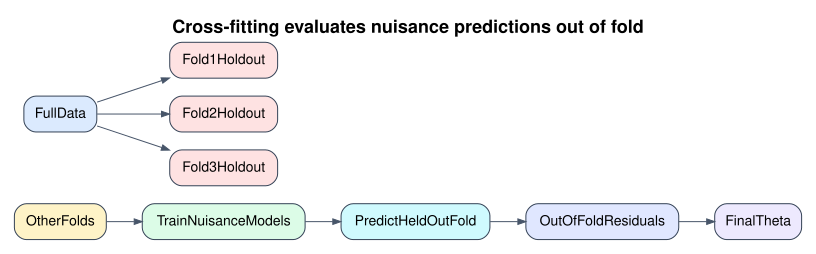

In [4]:
make_dag(
    edges=[
        ("FullData", "Fold1Holdout"),
        ("FullData", "Fold2Holdout"),
        ("FullData", "Fold3Holdout"),
        ("OtherFolds", "TrainNuisanceModels"),
        ("TrainNuisanceModels", "PredictHeldOutFold"),
        ("PredictHeldOutFold", "OutOfFoldResiduals"),
        ("OutOfFoldResiduals", "FinalTheta"),
    ],
    title="Cross-fitting evaluates nuisance predictions out of fold",
    node_colors={
        "FullData": "#dbeafe",
        "Fold1Holdout": "#fee2e2",
        "Fold2Holdout": "#fee2e2",
        "Fold3Holdout": "#fee2e2",
        "OtherFolds": "#fef3c7",
        "TrainNuisanceModels": "#dcfce7",
        "PredictHeldOutFold": "#cffafe",
        "OutOfFoldResiduals": "#e0e7ff",
        "FinalTheta": "#ede9fe",
    },
)

## 5. Running Example: Intervention Intensity

Imagine a SaaS company has an intervention that can be delivered with different intensity: more customer-success hours, more strategic reviews, more workflow consulting, or more enablement resources.

The business question is:

> What is the causal effect of one additional unit of intervention intensity on next-quarter account outcome?

This is observational. Account managers allocate more intervention intensity to accounts that look risky, new, complex, or valuable. The assignment rule is nonlinear. If we do not control flexibly for this assignment process, the treatment effect estimate will be badly biased.

In this simulation, the true structural effect is constant and known: one additional unit of intervention intensity increases the outcome by 3.4 units. The analyst does not observe that truth in real life; we use it here to test the estimators.

In [5]:
df = simulate_intervention_intensity_data()

base_feature_cols = [
    "risk_score",
    "engagement_score",
    "usage_z",
    "log_account_value",
    "tenure_months",
    "enterprise_plan",
    "support_tickets",
    "integration_count",
    "region_south",
    "region_west",
]
noise_feature_cols = [col for col in df.columns if col.startswith("noise_feature")]
feature_cols = base_feature_cols + noise_feature_cols

summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Treatment intensity mean",
            "Treatment intensity std",
            "Outcome mean",
            "True structural effect",
            "Corr(treatment, baseline outcome)",
            "Number of adjustment features",
        ],
        "value": [
            len(df),
            df["treatment_intensity"].mean(),
            df["treatment_intensity"].std(),
            df["outcome"].mean(),
            df["structural_effect"].iloc[0],
            df["treatment_intensity"].corr(df["baseline_outcome"]),
            len(feature_cols),
        ],
    }
)

display(summary.round(3))
display(df.head())

,quantity,value
0,Accounts,10000.000
1,Treatment intensity mean,3.728
2,Treatment intensity std,1.522
3,Outcome mean,97.223
4,True structural effect,3.400
5,"Corr(treatment, baseline outcome)",-0.358
6,Number of adjustment features,20.000


,account_id,risk_score,engagement_score,usage_z,log_account_value,account_value,tenure_months,enterprise_plan,support_tickets,integration_count,...,noise_feature_01,noise_feature_02,noise_feature_03,noise_feature_04,noise_feature_05,noise_feature_06,noise_feature_07,noise_feature_08,noise_feature_09,noise_feature_10
0,1,0.306,0.210,-0.171,4.088,59.621,24.540,1,1,6,...,0.702,-0.468,-0.254,1.471,0.429,0.484,-0.417,-0.246,-2.492,-0.205
1,2,0.548,0.559,-0.235,4.280,72.256,17.415,1,2,8,...,-1.533,-0.042,0.879,1.100,0.400,-0.091,-0.281,0.786,-0.263,1.734
2,3,0.323,0.314,-0.842,4.899,134.097,5.991,0,1,5,...,0.262,0.255,0.778,-1.558,-1.420,0.669,-0.945,0.588,-1.363,-0.316
3,4,0.602,0.136,-0.832,3.714,41.000,27.824,0,1,1,...,0.153,-1.484,0.708,1.191,-0.255,0.708,-0.681,-0.845,-0.166,1.632
4,5,0.202,0.869,-1.025,4.987,146.468,11.161,0,2,2,...,-0.260,-0.315,0.282,1.941,0.147,0.492,0.817,0.441,0.338,0.179


The treatment is negatively correlated with the baseline outcome in this simulation. Riskier accounts receive more intervention intensity, but they also have worse potential outcomes before the intervention. A naive regression will therefore make the intervention look less valuable than it is.

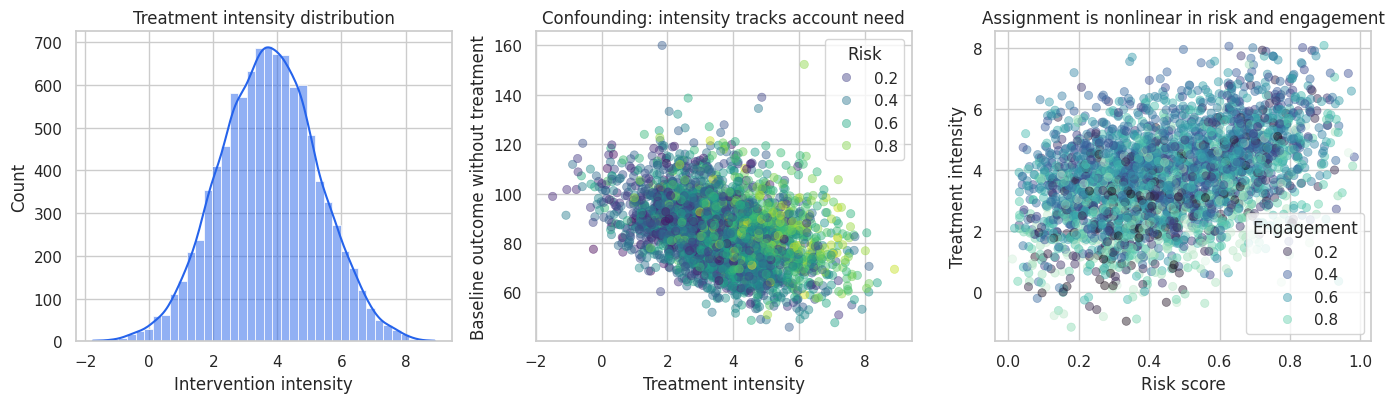

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.histplot(df["treatment_intensity"], bins=40, kde=True, color="#2563eb", ax=axes[0])
axes[0].set_title("Treatment intensity distribution")
axes[0].set_xlabel("Intervention intensity")

sns.scatterplot(
    data=df.sample(3000, random_state=4),
    x="treatment_intensity",
    y="baseline_outcome",
    hue="risk_score",
    palette="viridis",
    alpha=0.45,
    edgecolor=None,
    ax=axes[1],
)
axes[1].set_title("Confounding: intensity tracks account need")
axes[1].set_xlabel("Treatment intensity")
axes[1].set_ylabel("Baseline outcome without treatment")
axes[1].legend(title="Risk", loc="best")

sns.scatterplot(
    data=df.sample(3000, random_state=5),
    x="risk_score",
    y="treatment_intensity",
    hue="engagement_score",
    palette="mako",
    alpha=0.45,
    edgecolor=None,
    ax=axes[2],
)
axes[2].set_title("Assignment is nonlinear in risk and engagement")
axes[2].set_xlabel("Risk score")
axes[2].set_ylabel("Treatment intensity")
axes[2].legend(title="Engagement", loc="best")

plt.tight_layout()
plt.show()

## 6. Naive and Misspecified Estimates

Start with two familiar regressions:

1. Naive regression: regress outcome on treatment intensity only.
2. Linear adjustment: regress outcome on treatment intensity and raw covariates linearly.

The second model controls for more information, but it still misses the nonlinear assignment and baseline-outcome patterns in the data-generating process.

In [7]:
naive_estimate = estimate_linear_ols(df, covariates=[])
linear_estimate = estimate_linear_ols(df, covariates=base_feature_cols)

initial_estimates = pd.DataFrame(
    [
        {"estimator": "Naive OLS", **naive_estimate},
        {"estimator": "Linear adjustment", **linear_estimate},
        {
            "estimator": "True structural effect",
            "estimate": df["structural_effect"].iloc[0],
            "std_error": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        },
    ]
)

display(initial_estimates.round(3))

,estimator,estimate,std_error,ci_low,ci_high
0,Naive OLS,0.193,0.095,0.006,0.379
1,Linear adjustment,1.721,0.090,1.545,1.898
2,True structural effect,3.400,NaN,NaN,NaN


The naive estimate is badly biased because high-need accounts receive more intensity. The linear adjustment improves the setup but still misses important nonlinear confounding patterns.

This is exactly where DML is useful: use flexible nuisance models for the complicated parts while preserving a simple, interpretable causal target.

## 7. Cross-Fitted DML With Flexible Nuisance Models

We will use gradient-boosted trees for the nuisance functions:

$$
\hat{l}(X) \approx E[Y \mid X]
$$

$$
\hat{m}(X) \approx E[D \mid X]
$$

Then DML estimates the treatment effect from the out-of-fold residuals.

In [8]:
gbdt_y = HistGradientBoostingRegressor(
    max_iter=260,
    learning_rate=0.04,
    min_samples_leaf=35,
    l2_regularization=0.01,
    random_state=5,
)
gbdt_d = clone(gbdt_y)

dml_gbdt = dml_partial_linear(
    df,
    feature_cols,
    outcome_col="outcome",
    treatment_col="treatment_intensity",
    outcome_model=gbdt_y,
    treatment_model=gbdt_d,
    n_splits=5,
    seed=202,
)

pd.DataFrame(
    {
        "quantity": [
            "DML estimate",
            "Robust standard error",
            "95% CI lower",
            "95% CI upper",
            "True structural effect",
            "Outcome nuisance R2",
            "Treatment nuisance R2",
            "Outcome nuisance RMSE",
            "Treatment nuisance RMSE",
        ],
        "value": [
            dml_gbdt["theta"],
            dml_gbdt["std_error"],
            dml_gbdt["ci_low"],
            dml_gbdt["ci_high"],
            df["structural_effect"].iloc[0],
            dml_gbdt["r2_y"],
            dml_gbdt["r2_d"],
            dml_gbdt["rmse_y"],
            dml_gbdt["rmse_d"],
        ],
    }
).round(3)

,quantity,value
0,DML estimate,3.335
1,Robust standard error,0.079
2,95% CI lower,3.180
3,95% CI upper,3.489
4,True structural effect,3.400
5,Outcome nuisance R2,0.699
6,Treatment nuisance R2,0.622
7,Outcome nuisance RMSE,8.011
8,Treatment nuisance RMSE,0.935


The DML estimate is much closer to the true structural effect than the naive and misspecified estimates. The confidence interval is based on the orthogonal score, not on treating the nuisance models as if they were fixed known functions.

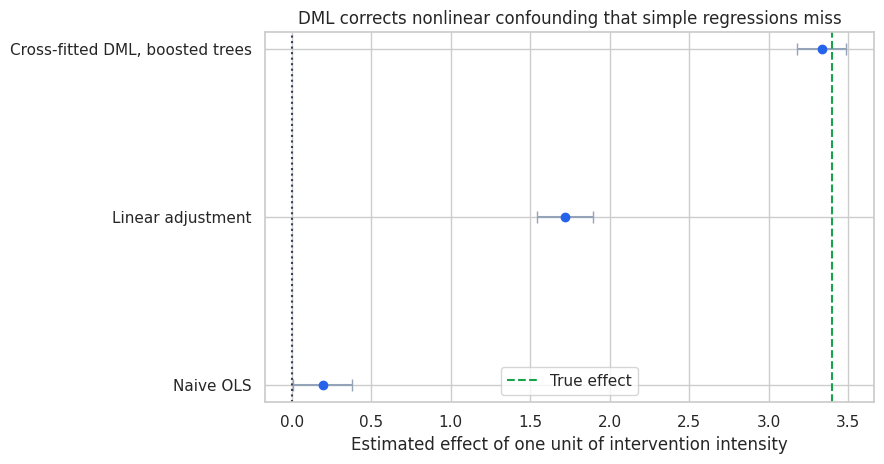

,estimator,estimate,std_error,ci_low,ci_high
0,Naive OLS,0.193,0.095,0.006,0.379
1,Linear adjustment,1.721,0.090,1.545,1.898
2,"Cross-fitted DML, boosted trees",3.335,0.079,3.180,3.489


In [9]:
comparison_rows = [
    {"estimator": "Naive OLS", **naive_estimate},
    {"estimator": "Linear adjustment", **linear_estimate},
    {
        "estimator": "Cross-fitted DML, boosted trees",
        "estimate": dml_gbdt["theta"],
        "std_error": dml_gbdt["std_error"],
        "ci_low": dml_gbdt["ci_low"],
        "ci_high": dml_gbdt["ci_high"],
    },
]
comparison = pd.DataFrame(comparison_rows)

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(comparison))
ax.errorbar(
    comparison["estimate"],
    y,
    xerr=np.vstack([
        comparison["estimate"] - comparison["ci_low"],
        comparison["ci_high"] - comparison["estimate"],
    ]),
    fmt="o",
    color="#2563eb",
    ecolor="#94a3b8",
    capsize=4,
)
ax.axvline(df["structural_effect"].iloc[0], color="#16a34a", linestyle="--", label="True effect")
ax.axvline(0, color="#334155", linestyle=":")
ax.set_yticks(y)
ax.set_yticklabels(comparison["estimator"])
ax.set_xlabel("Estimated effect of one unit of intervention intensity")
ax.set_title("DML corrects nonlinear confounding that simple regressions miss")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

display(comparison.round(3))

## 8. Residualized Regression View

The final DML step is a regression of residualized outcome on residualized treatment. If the nuisance models remove the confounding structure, the slope in this residual plot estimates the causal effect.

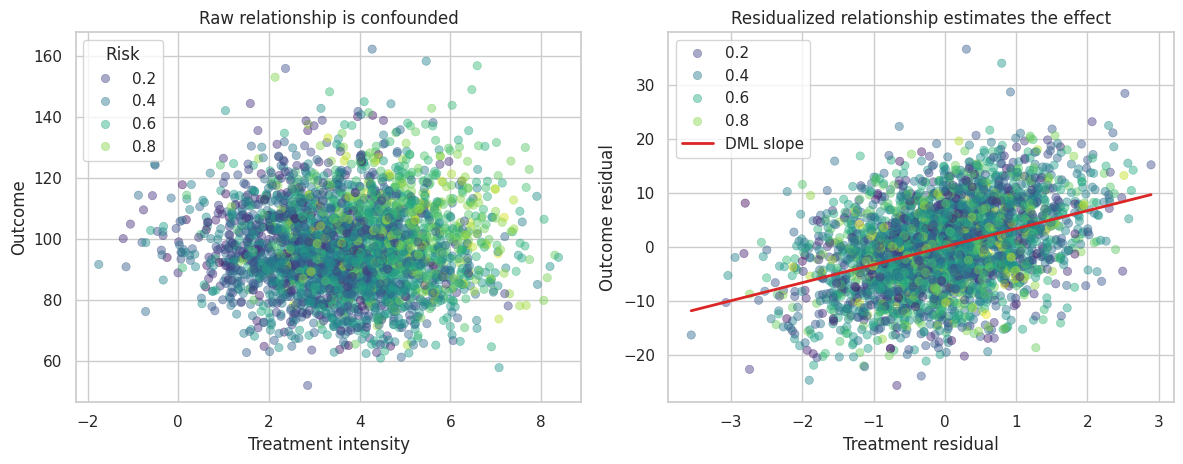

In [10]:
diag = dml_gbdt["diagnostics"].copy()
diag["outcome"] = df["outcome"]
diag["treatment_intensity"] = df["treatment_intensity"]
diag["risk_score"] = df["risk_score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(
    data=diag.sample(3000, random_state=44),
    x="treatment_intensity",
    y="outcome",
    hue="risk_score",
    palette="viridis",
    alpha=0.45,
    edgecolor=None,
    ax=axes[0],
)
axes[0].set_title("Raw relationship is confounded")
axes[0].set_xlabel("Treatment intensity")
axes[0].set_ylabel("Outcome")
axes[0].legend(title="Risk", loc="best")

sample_resid = diag.sample(3000, random_state=45)
sns.scatterplot(
    data=sample_resid,
    x="d_residual",
    y="y_residual",
    hue="risk_score",
    palette="viridis",
    alpha=0.45,
    edgecolor=None,
    ax=axes[1],
)
line_x = np.linspace(sample_resid["d_residual"].min(), sample_resid["d_residual"].max(), 100)
axes[1].plot(line_x, dml_gbdt["theta"] * line_x, color="#dc2626", linewidth=2, label="DML slope")
axes[1].set_title("Residualized relationship estimates the effect")
axes[1].set_xlabel("Treatment residual")
axes[1].set_ylabel("Outcome residual")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

The residualized view is often the easiest way to explain DML to stakeholders. We first remove the part of treatment and outcome that can be predicted from covariates, then estimate the relationship between the remaining variation.

## 9. Cross-Fitting Versus Same-Sample Residualization

Cross-fitting is not cosmetic. It prevents the nuisance models from using an observation to predict itself.

Here we compare:

- Same-sample residualization: nuisance models trained and predicted on the full data.
- Cross-fitted residualization: each nuisance prediction is out of fold.

Same-sample residualization can look more accurate by in-sample prediction metrics but still distort the final residuals.

In [11]:
same_sample_gbdt = same_sample_residualization(
    df,
    feature_cols,
    outcome_col="outcome",
    treatment_col="treatment_intensity",
    outcome_model=gbdt_y,
    treatment_model=gbdt_d,
)

crossfit_vs_same = pd.DataFrame(
    [
        {
            "approach": "Same-sample residualization",
            "theta": same_sample_gbdt["theta"],
            "outcome_r2": same_sample_gbdt["r2_y"],
            "treatment_r2": same_sample_gbdt["r2_d"],
            "treatment_residual_sd": same_sample_gbdt["d_residual_sd"],
        },
        {
            "approach": "Cross-fitted DML",
            "theta": dml_gbdt["theta"],
            "outcome_r2": dml_gbdt["r2_y"],
            "treatment_r2": dml_gbdt["r2_d"],
            "treatment_residual_sd": dml_gbdt["diagnostics"]["d_residual"].std(),
        },
    ]
)

display(crossfit_vs_same.round(3))

,approach,theta,outcome_r2,treatment_r2,treatment_residual_sd
0,Same-sample residualization,3.377,0.810,0.760,0.745
1,Cross-fitted DML,3.335,0.699,0.622,0.935


The same-sample nuisance models can report stronger in-sample fit. DML prefers out-of-fold nuisance predictions because the residuals should represent unseen variation, not training-set memorization.

## 10. Sensitivity to the Nuisance Learner

DML reduces sensitivity to nuisance errors, but it does not make the nuisance learner irrelevant. If the nuisance learner cannot approximate the important nonlinear confounding structure, the final estimate can still be biased.

We compare three nuisance strategies:

- Ridge regression on standardized features: mostly linear.
- Random forest: flexible but not always ideal for smooth nuisance functions.
- Gradient-boosted trees: flexible and well matched to this simulation.

,learner,theta,std_error,ci_low,ci_high,outcome_r2,treatment_r2
0,Ridge nuisance,1.717,0.090,1.540,1.894,0.531,0.500
1,Random forest nuisance,2.804,0.087,2.633,2.975,0.630,0.579
2,Boosted-tree nuisance,3.323,0.079,3.168,3.478,0.699,0.622


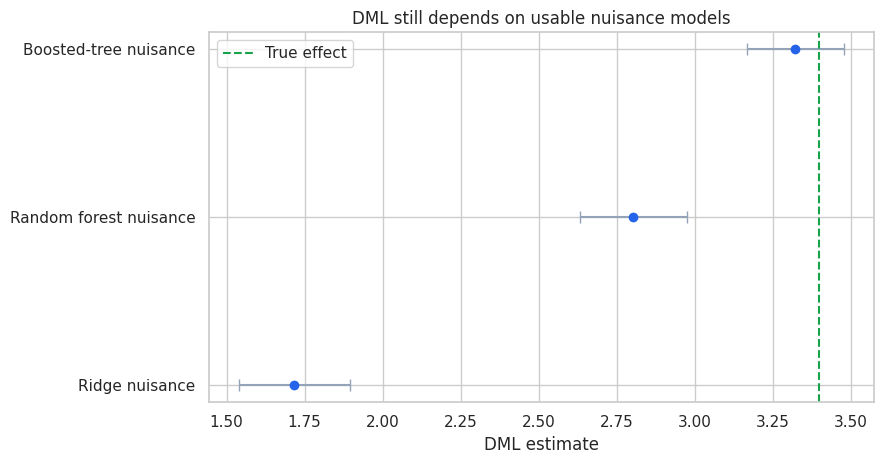

In [12]:
ridge_model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 20)))
rf_model = RandomForestRegressor(
    n_estimators=220,
    min_samples_leaf=35,
    random_state=7,
    n_jobs=-1,
)

nuisance_results = []
for label, model in [
    ("Ridge nuisance", ridge_model),
    ("Random forest nuisance", rf_model),
    ("Boosted-tree nuisance", gbdt_y),
]:
    result = dml_partial_linear(
        df,
        feature_cols,
        outcome_col="outcome",
        treatment_col="treatment_intensity",
        outcome_model=model,
        treatment_model=clone(model),
        n_splits=5,
        seed=310,
    )
    nuisance_results.append(
        {
            "learner": label,
            "theta": result["theta"],
            "std_error": result["std_error"],
            "ci_low": result["ci_low"],
            "ci_high": result["ci_high"],
            "outcome_r2": result["r2_y"],
            "treatment_r2": result["r2_d"],
        }
    )

nuisance_table = pd.DataFrame(nuisance_results)
display(nuisance_table.round(3))

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(nuisance_table))
ax.errorbar(
    nuisance_table["theta"],
    y,
    xerr=np.vstack([
        nuisance_table["theta"] - nuisance_table["ci_low"],
        nuisance_table["ci_high"] - nuisance_table["theta"],
    ]),
    fmt="o",
    color="#2563eb",
    ecolor="#94a3b8",
    capsize=4,
)
ax.axvline(df["structural_effect"].iloc[0], color="#16a34a", linestyle="--", label="True effect")
ax.set_yticks(y)
ax.set_yticklabels(nuisance_table["learner"])
ax.set_xlabel("DML estimate")
ax.set_title("DML still depends on usable nuisance models")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

A poor nuisance learner can leave confounding in the residuals. Orthogonality protects against small nuisance errors, not arbitrary misspecification. This is why DML workflows still need nuisance diagnostics and sensitivity analysis.

## 11. Fold Diagnostics

DML estimates nuisance predictions fold by fold. Fold-level diagnostics can catch data splits where the nuisance models perform poorly or where treatment residual variation is too small.

,fold,n,theta_from_fold_residuals,treatment_residual_sd,outcome_residual_sd,score_mean
0,1,2000,3.326,0.924,8.014,-0.008
1,2,2000,3.261,0.941,7.991,-0.066
2,3,2000,3.277,0.927,8.076,-0.050
3,4,2000,3.596,0.942,8.011,0.232
4,5,2000,3.212,0.942,7.971,-0.109


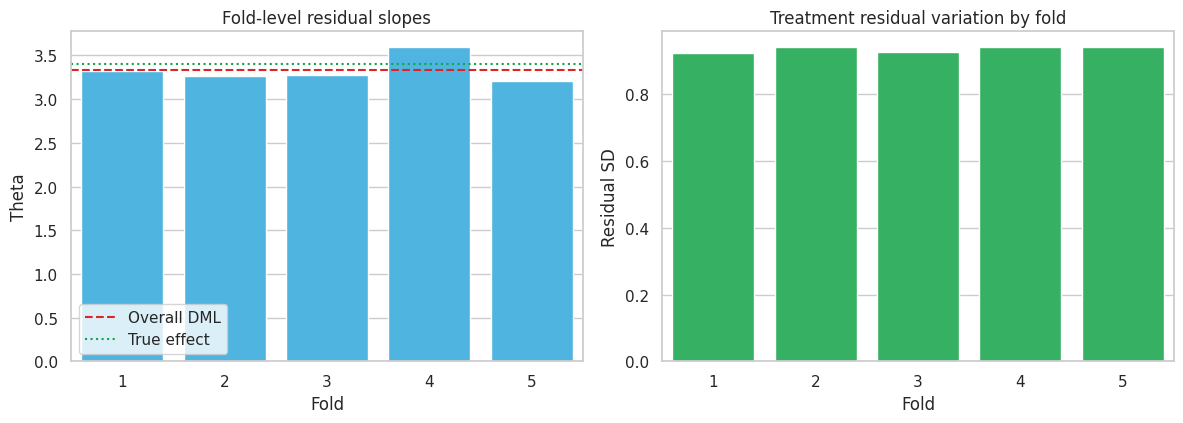

In [13]:
fold_rows = []
for fold_id, group in diag.groupby("fold"):
    theta_fold = np.sum(group["d_residual"] * group["y_residual"]) / np.sum(group["d_residual"] ** 2)
    fold_rows.append(
        {
            "fold": fold_id,
            "n": len(group),
            "theta_from_fold_residuals": theta_fold,
            "treatment_residual_sd": group["d_residual"].std(),
            "outcome_residual_sd": group["y_residual"].std(),
            "score_mean": group["score"].mean(),
        }
    )

fold_table = pd.DataFrame(fold_rows)
display(fold_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=fold_table, x="fold", y="theta_from_fold_residuals", color="#38bdf8", ax=axes[0])
axes[0].axhline(dml_gbdt["theta"], color="#dc2626", linestyle="--", label="Overall DML")
axes[0].axhline(df["structural_effect"].iloc[0], color="#16a34a", linestyle=":", label="True effect")
axes[0].set_title("Fold-level residual slopes")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Theta")
axes[0].legend(loc="best")

sns.barplot(data=fold_table, x="fold", y="treatment_residual_sd", color="#22c55e", ax=axes[1])
axes[1].set_title("Treatment residual variation by fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Residual SD")

plt.tight_layout()
plt.show()

Fold estimates should not be identical, but extreme fold instability is a warning sign. It can indicate poor overlap, weak residual treatment variation, data leakage, or a nuisance model that is unstable across samples.

## 12. Testing Low-Dimensional Effect Modifiers

DML can also estimate low-dimensional interaction parameters after residualization. Suppose the business asks whether the intervention intensity effect differs by risk, engagement, or enterprise plan.

We can fit a residualized interaction model:

$$
\tilde{Y}_i = \tilde{D}_i(\theta_0 + \theta_1 Z_{i1} + \theta_2 Z_{i2} + \theta_3 Z_{i3}) + error_i
$$

where $Z$ contains pre-treatment effect modifiers. In this simulation, the true structural effect is constant, so strong interactions would be false positives.

In [14]:
modifier_frame = pd.DataFrame(index=df.index)
modifier_frame["intercept"] = 1.0
for col in ["risk_score", "engagement_score", "enterprise_plan"]:
    if df[col].std() > 0:
        modifier_frame[col] = (df[col] - df[col].mean()) / df[col].std()
    else:
        modifier_frame[col] = df[col]

interaction_design = modifier_frame.mul(diag["d_residual"], axis=0)
interaction_model = sm.OLS(diag["y_residual"], interaction_design).fit(cov_type="HC3")
interaction_table = pd.DataFrame(
    {
        "term": interaction_model.params.index,
        "estimate": interaction_model.params.values,
        "std_error": interaction_model.bse.values,
        "ci_low": interaction_model.conf_int()[0].values,
        "ci_high": interaction_model.conf_int()[1].values,
        "p_value": interaction_model.pvalues.values,
    }
)

display(interaction_table.round(3))

,term,estimate,std_error,ci_low,ci_high,p_value
0,intercept,3.329,0.079,3.174,3.483,0.000
1,risk_score,-0.002,0.080,-0.158,0.153,0.975
2,engagement_score,0.025,0.080,-0.131,0.182,0.750
3,enterprise_plan,0.293,0.079,0.138,0.447,0.000


This is not a full nonparametric CATE model. It is a targeted, low-dimensional heterogeneity test using the same residualization idea. For rich heterogeneity, use R-learners, DR-learners, causal forests, or other CATE methods and validate them by policy value and bucket lift.

## 13. What DML Does Not Solve

DML is powerful, but it is not magic.

It does not solve:

- Unobserved confounding.
- Bad treatment definition.
- Bad outcome timing.
- Post-treatment controls.
- Positivity violations where no comparable units exist.
- Data leakage from future information.
- Weak residual treatment variation.
- Business objectives that differ from the estimated parameter.

DML helps when the causal identification strategy is credible and the hard part is flexibly adjusting for observed covariates without invalidating inference on the target parameter.

## 14. DML Versus Doubly Robust Estimation

The phrase "double/debiased machine learning" can be confusing.

DML usually refers to the broader framework: use orthogonal scores and cross-fitting so ML nuisance estimates can be used for valid inference on causal or structural parameters.

Doubly robust estimators are a related but distinct family. A doubly robust ATE estimator can be consistent if either the outcome model or the propensity model is correct. Many doubly robust scores can be used inside a DML-style cross-fitting workflow.

So the relationship is:

- DML: orthogonal scores plus cross-fitting as a general estimation framework.
- Doubly robust AIPW/TMLE-style estimators: specific orthogonal scores with robustness properties for certain causal parameters.
- R-learner and DR-learner: CATE-oriented learners that use residualization or doubly robust pseudo-outcomes.

Kennedy (2023) studies doubly robust estimation for heterogeneous effects, while Nie and Wager (2020) connect residualized loss functions to heterogeneous treatment-effect estimation.

## 15. Industry Readout Template

For an applied DML project, the final readout should make the identification strategy and diagnostics visible:

1. Estimand: one-unit increase in intervention intensity on next-quarter account outcome.
2. Identification: assumes no unobserved confounding after pre-treatment account features.
3. Nuisance models: outcome and treatment assignment models trained out of fold.
4. Main estimate: DML point estimate, standard error, and confidence interval.
5. Diagnostics: nuisance R2/RMSE, treatment residual variation, fold stability, overlap checks.
6. Sensitivity: compare several nuisance learners and simple baselines.
7. Business implication: translate effect per unit into marginal ROI and capacity decisions.
8. Guardrail: do not extrapolate outside regions with residual treatment variation.

In [15]:
readout = pd.DataFrame(
    {
        "item": [
            "Target parameter",
            "Main DML estimate",
            "True effect in simulation",
            "Why naive OLS fails",
            "Most important diagnostic",
            "Deployment implication",
        ],
        "value": [
            "Effect of one additional unit of intervention intensity",
            f"{dml_gbdt['theta']:.2f} [{dml_gbdt['ci_low']:.2f}, {dml_gbdt['ci_high']:.2f}]",
            f"{df['structural_effect'].iloc[0]:.2f}",
            "High-need accounts receive more intensity and have lower baseline outcomes.",
            "Out-of-fold treatment residual variation and fold-level slope stability.",
            "Use the effect estimate for marginal ROI only inside the observed support.",
        ],
    }
)

display(readout)

,item,value
0,Target parameter,Effect of one additional unit of intervention ...
1,Main DML estimate,"3.33 [3.18, 3.49]"
2,True effect in simulation,3.40
3,Why naive OLS fails,High-need accounts receive more intensity and ...
4,Most important diagnostic,Out-of-fold treatment residual variation and f...
5,Deployment implication,Use the effect estimate for marginal ROI only ...


## Key Takeaways

- DML estimates a low-dimensional causal parameter while using ML for high-dimensional nuisance functions.
- Orthogonal scores reduce first-order sensitivity to nuisance-model errors.
- Cross-fitting prevents own-observation overfitting from contaminating residuals.
- The partially linear DML estimator is a residualized regression of outcome residuals on treatment residuals.
- DML still requires a credible identification strategy and usable nuisance models.
- Nuisance diagnostics, fold stability, and residual treatment variation are central to applied DML.
- DML complements, rather than replaces, CATE methods such as R-learners, DR-learners, and causal forests.

## References

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal, 21*(1), C1-C68. https://doi.org/10.1111/ectj.12097

Emmenegger, C., & Buhlmann, P. (2021). Regularizing double machine learning in partially linear endogenous models. *Electronic Journal of Statistics, 15*(2), 5978-6016. https://doi.org/10.1214/21-EJS1931

Jung, Y., Tian, J., & Bareinboim, E. (2021). Estimating identifiable causal effects through double machine learning. *Proceedings of the AAAI Conference on Artificial Intelligence, 35*(13), 12113-12122. https://doi.org/10.1609/aaai.v35i13.17438

Kennedy, E. H. (2023). Towards optimal doubly robust estimation of heterogeneous causal effects. *Electronic Journal of Statistics, 17*(2). https://doi.org/10.1214/23-EJS2157

Nie, X., & Wager, S. (2020). Quasi-oracle estimation of heterogeneous treatment effects. *Biometrika, 108*(2), 299-319. https://doi.org/10.1093/biomet/asaa076